# Intel Scene Classification — Improved CNN Experiments

## Professional Report Notebook

> **Important:** This is the **report/analysis version** of the notebook.  
> The models were already trained and evaluated during the practical work, so the cells below use the **recorded training results** rather than calling `model.fit()` again.

This design lets the notebook be run from top to bottom without repeating the long training process.

The practical workflow remains:

**Baseline → observe the result → identify a possible limitation → select a CNN technique from the lecture → test it → evaluate on the test set → compare → decide the next step.**


## 1. Dataset and Experimental Setup

The same Intel Scene Classification dataset was used throughout the experiments.

- Image size: **150 × 150**
- Batch size: **32**
- Number of classes: **6**
- Classes: `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`
- Validation split: **10%**
- Epochs per experiment: **10**

The dataset and preprocessing were kept consistent so that the comparison focuses on the CNN changes rather than on different data settings.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("Number of classes:", len(class_names))
print("Classes:", class_names)
print("Image size: 150 x 150")
print("Batch size: 32")
print("Validation split: 10%")


Number of classes: 6
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Image size: 150 x 150
Batch size: 32
Validation split: 10%


# 2. Baseline CNN — Reference Model

The baseline is the reference point for the entire improvement process.

It uses the basic CNN pipeline developed in the first notebook:

**Convolution → Pooling → Convolution → Pooling → Convolution → Flatten → Dense → Output**

The baseline achieved **77.60% test accuracy**.

This number is important because every later modification is judged against it.


In [2]:
histories = {
    "Baseline CNN": {"accuracy": [0.6590,0.7751,0.8276,0.8838,0.9216,0.9513,0.9655,0.9696,0.9816,0.9795],
                     "val_accuracy": [0.8311,0.8304,0.9408,0.9487,0.9351,0.9715,0.9515,0.9751,0.9836,0.9779],
                     "loss": [0.9059,0.6075,0.4649,0.3202,0.2251,0.1403,0.1047,0.0957,0.0600,0.0637],
                     "val_loss": [0.4575,0.4349,0.1860,0.1797,0.2269,0.1219,0.2058,0.1146,0.0885,0.1242],
                     "test_accuracy": 0.7760, "test_loss": 1.2202},
    "Lighter Dropout (0.2)": {"accuracy": [0.5299,0.6575,0.7259,0.7659,0.7927,0.8299,0.8459,0.8618,0.8676,0.8817],
                     "val_accuracy": [0.7976,0.8261,0.9038,0.9123,0.6094,0.3685,0.9351,0.9701,0.9636,0.9644],
                     "loss": [2.1812,0.9663,0.7380,0.6440,0.5542,0.4494,0.4235,0.3701,0.3635,0.3228],
                     "val_loss": [0.9225,0.7129,0.3005,0.2775,1.9918,6.2425,0.1999,0.1165,0.1486,0.1001],
                     "test_accuracy": 0.6547, "test_loss": 1.8010},
    "Global Average Pooling": {"accuracy": [0.4556,0.6020,0.6643,0.6866,0.7140,0.7277,0.7428,0.7557,0.7691,0.7794],
                     "val_accuracy": [0.4148,0.8289,0.7847,0.8275,0.8011,0.7919,0.8411,0.8639,0.7805,0.8710],
                     "loss": [1.2861,0.9787,0.8541,0.8040,0.7488,0.7178,0.6830,0.6506,0.6173,0.5965],
                     "val_loss": [1.4018,0.6648,0.6571,0.6267,0.5540,0.6888,0.4828,0.4536,0.5619,0.4045],
                     "test_accuracy": 0.7747, "test_loss": 0.5996},
    "Residual + GAP": {"accuracy": [0.4582,0.6094,0.6824,0.7265,0.7473,0.7705,0.7797,0.7972,0.8069,0.8128],
                     "val_accuracy": [0.8104,0.7384,0.8232,0.7733,0.8147,0.8076,0.7313,0.8297,0.7591,0.8959],
                     "loss": [1.2721,0.9636,0.8230,0.7317,0.6733,0.6272,0.5939,0.5519,0.5225,0.4987],
                     "val_loss": [0.7093,0.8733,0.6098,0.6426,0.5306,0.5098,0.6289,0.4448,0.5837,0.2850],
                     "test_accuracy": 0.8177, "test_loss": 0.4943}
}
results = {
    name: {key: np.array(value) if isinstance(value, list) else value for key, value in data.items()}
    for name, data in histories.items()
}
baseline_cm = np.array([[321,8,4,6,9,89],[5,444,2,6,2,15],[12,7,372,89,59,14],[9,4,67,378,63,4],[19,2,39,48,397,5],[48,15,5,3,14,416]])
residual_cm = np.array([[322,6,3,17,10,79],[1,437,3,6,1,26],[12,5,337,152,27,20],[13,4,42,453,10,3],[25,4,70,131,266,14],[42,10,1,7,5,436]])


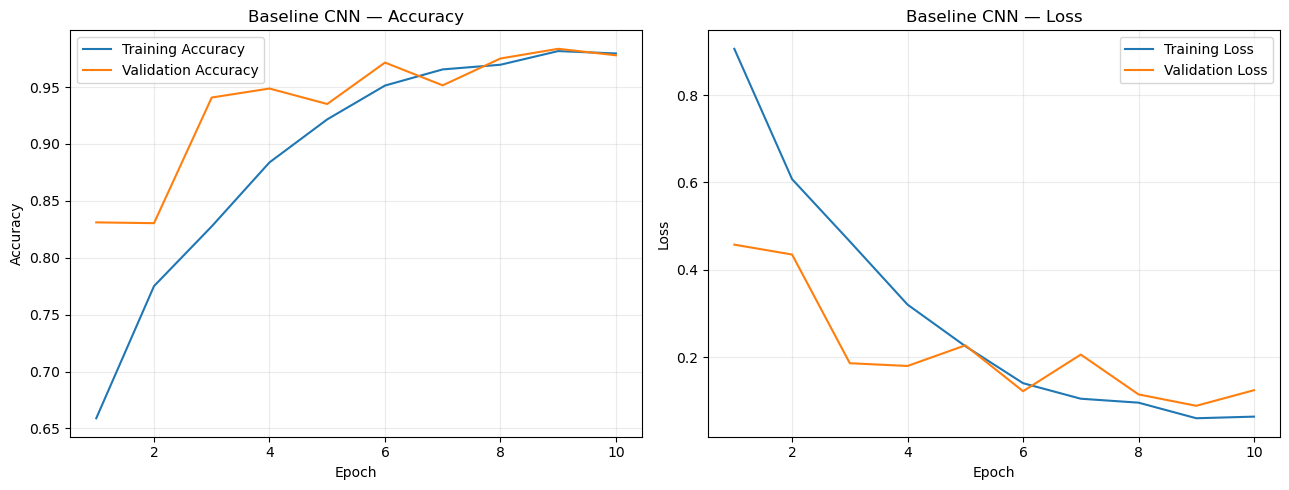

In [3]:
baseline = results["Baseline CNN"]
epochs = np.arange(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, baseline["accuracy"], label="Training Accuracy")
axes[0].plot(epochs, baseline["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Baseline CNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, baseline["loss"], label="Training Loss")
axes[1].plot(epochs, baseline["val_loss"], label="Validation Loss")
axes[1].set_title("Baseline CNN — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [4]:
print(f"Baseline Test Loss: {baseline['test_loss']:.4f}")
print(f"Baseline Test Accuracy: {baseline['test_accuracy']:.4f}")


Baseline Test Loss: 1.2202
Baseline Test Accuracy: 0.7760


### Baseline Observation

The baseline gives us a solid reference, but the learning curves and class-level errors show that some scene categories are visually difficult to separate.

Examples of recurring confusion include:

- **glacier ↔ mountain**
- **sea ↔ mountain**
- **buildings ↔ street**

This observation motivates testing CNN techniques that can improve feature learning or the way extracted features are represented.


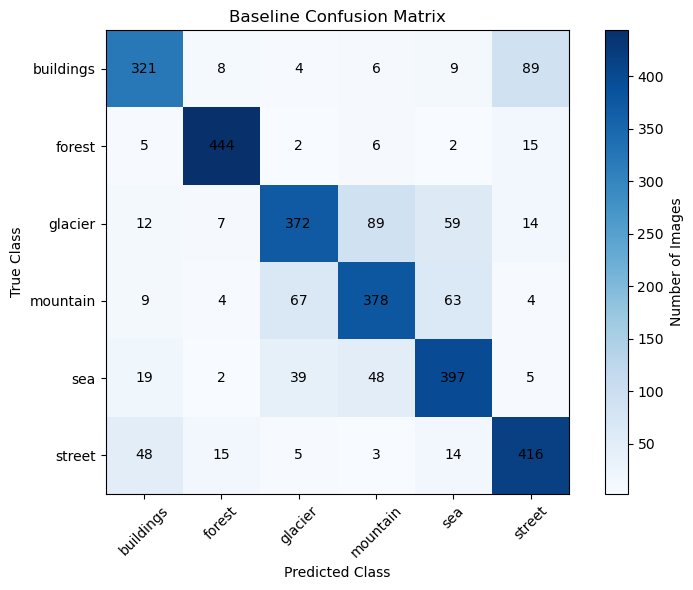

In [5]:
baseline_cm = np.array(baseline_cm)

plt.figure(figsize=(8, 6))
plt.imshow(baseline_cm, cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(6), class_names, rotation=45)
plt.yticks(range(6), class_names)

for i in range(6):
    for j in range(6):
        plt.text(j, i, baseline_cm[i, j], ha="center", va="center")

plt.colorbar(label="Number of Images")
plt.tight_layout()
plt.show()


# 3. Experiment 1 — Lighter Dropout

## Why did we try it?

Dropout is used as a regularization technique. The practical model used a relatively stronger Dropout value, so we tested whether reducing it would allow the network to retain more useful information.

This is a **small and controlled modification**, not a new architecture.

### Result

The test accuracy fell to **65.47%**, compared with the baseline's **77.60%**.

Therefore, this modification was **rejected**.

This is an important practical conclusion: a change that sounds reasonable theoretically does not automatically improve this particular dataset.


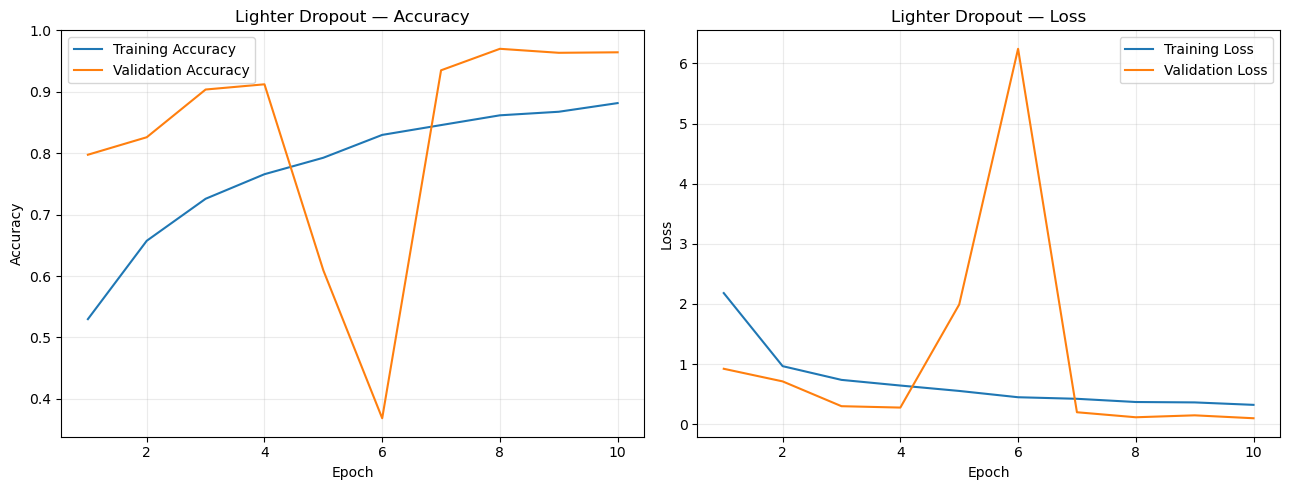

Test Accuracy: 65.47%


In [6]:
light = results["Lighter Dropout (0.2)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, light["accuracy"], label="Training Accuracy")
axes[0].plot(epochs, light["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Lighter Dropout — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, light["loss"], label="Training Loss")
axes[1].plot(epochs, light["val_loss"], label="Validation Loss")
axes[1].set_title("Lighter Dropout — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Test Accuracy: {light['test_accuracy']:.2%}")


# 4. Experiment 2 — Global Average Pooling

## Why did we move to Global Pooling?

The baseline architecture uses `Flatten` after the convolutional layers.

For the current feature-map size, Flatten produces a large vector, which then feeds a Dense layer with millions of parameters.

Global Average Pooling provides a more compact way to summarize the feature maps.

So the question was:

> Can we reduce the classifier size while maintaining good classification performance?

### Result

The Global Average Pooling model achieved **77.47% test accuracy**.

This is almost the same as the baseline (**77.60%**), so it did not improve the final accuracy, but it demonstrated that a much more compact representation can maintain comparable performance.

Because accuracy is our main task metric, we did not select it as the final model.


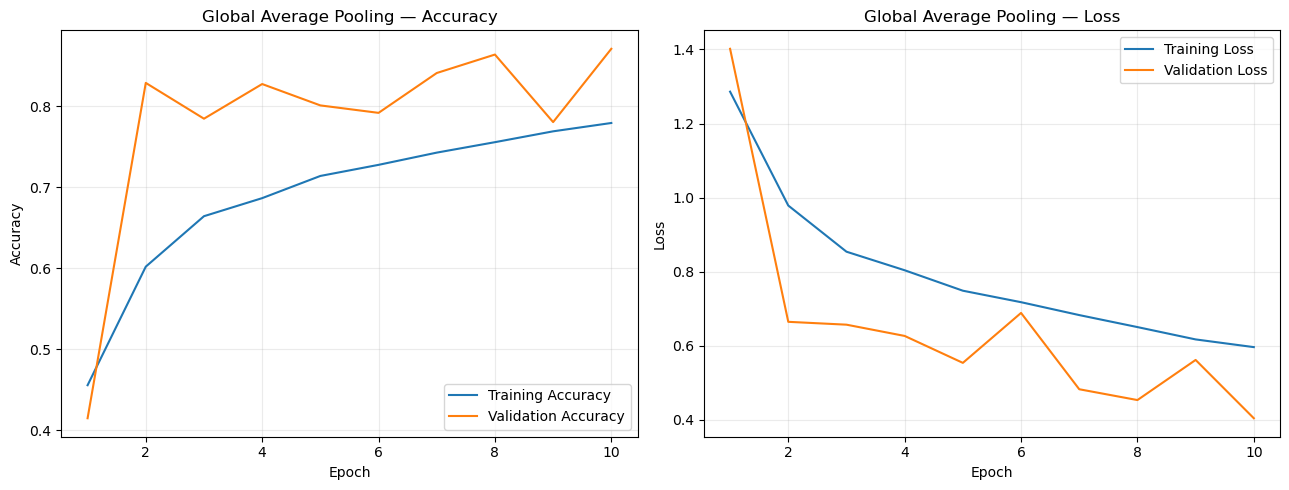

Test Accuracy: 77.47%


In [7]:
gap = results["Global Average Pooling"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, gap["accuracy"], label="Training Accuracy")
axes[0].plot(epochs, gap["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Global Average Pooling — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, gap["loss"], label="Training Loss")
axes[1].plot(epochs, gap["val_loss"], label="Validation Loss")
axes[1].set_title("Global Average Pooling — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Test Accuracy: {gap['test_accuracy']:.2%}")


# 5. Experiment 3 — Residual Block + Global Average Pooling

## Why did we try a Residual Connection?

After the previous experiments:

- Lighter Dropout **reduced** test performance.
- Global Average Pooling produced performance very close to the baseline, but did not exceed it.

The theoretical material introduces **Residual Blocks** as a CNN technique that uses a shortcut connection to help information pass through the network.

Instead of building a large ResNet, we tested a **small residual block** and kept Global Average Pooling as the compact classifier representation.

This gives us a targeted experiment based on the concepts covered in the lecture.

### Result

The model achieved:

**Test Accuracy = 81.77%**

Compared with the baseline:

**81.77% − 77.60% = +4.17 percentage points**

This is the first experiment that clearly improves the baseline, so it becomes our selected model.


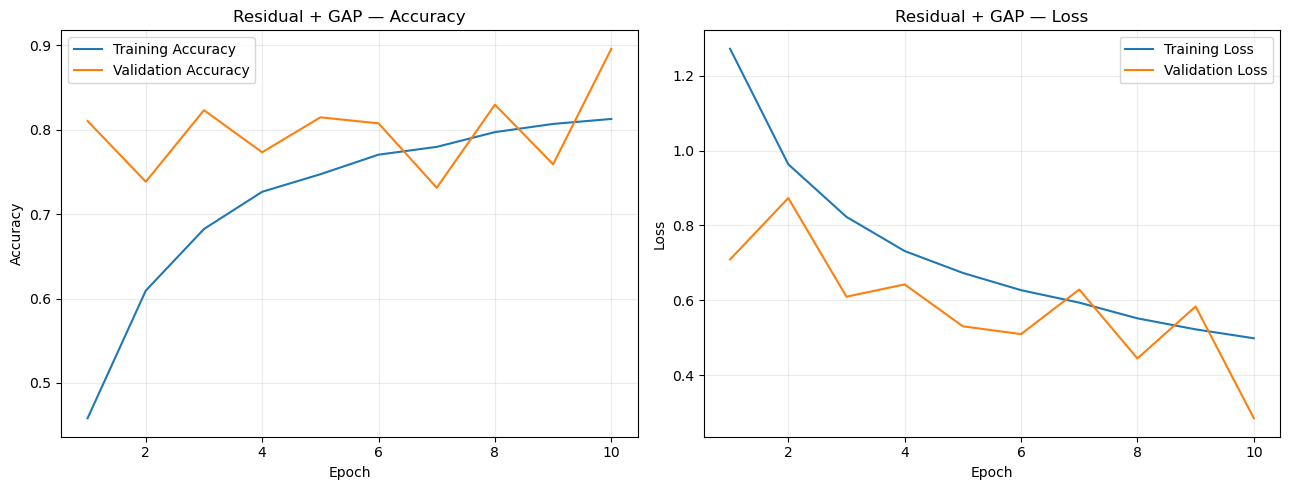

Test Loss: 0.4943
Test Accuracy: 81.77%


In [8]:
residual = results["Residual + GAP"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, residual["accuracy"], label="Training Accuracy")
axes[0].plot(epochs, residual["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Residual + GAP — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, residual["loss"], label="Training Loss")
axes[1].plot(epochs, residual["val_loss"], label="Validation Loss")
axes[1].set_title("Residual + GAP — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Test Loss: {residual['test_loss']:.4f}")
print(f"Test Accuracy: {residual['test_accuracy']:.2%}")


## 6. Final Model Error Analysis

Since the Residual + GAP model achieved the best test accuracy, we repeat the confusion-matrix analysis for the selected model.

This allows us to inspect the improvement at the class level rather than relying on the accuracy value alone.


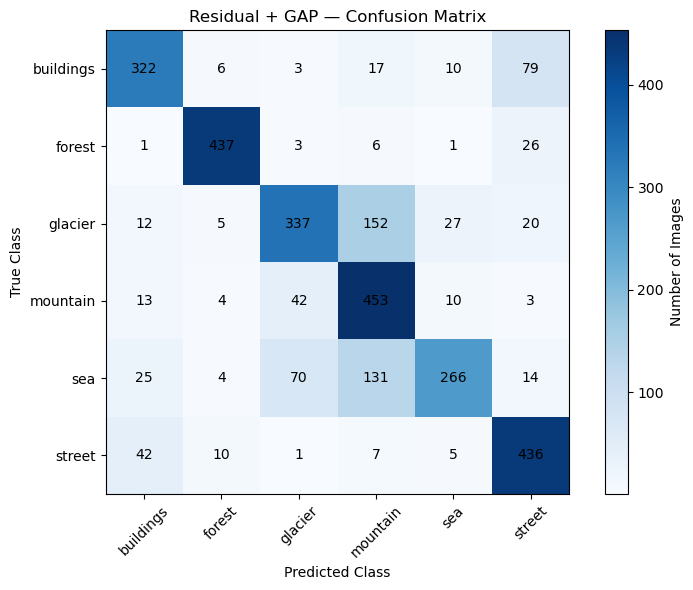

In [9]:
residual_cm = np.array(residual_cm)

plt.figure(figsize=(8, 6))
plt.imshow(residual_cm, cmap="Blues")
plt.title("Residual + GAP — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(6), class_names, rotation=45)
plt.yticks(range(6), class_names)

for i in range(6):
    for j in range(6):
        plt.text(j, i, residual_cm[i, j], ha="center", va="center")

plt.colorbar(label="Number of Images")
plt.tight_layout()
plt.show()


# 7. Final Comparison

The test-set accuracy is the final comparison metric because the test images were not used to update the model weights.

The results are:

| Model | Test Accuracy |
|---|---:|
| Baseline CNN | **77.60%** |
| Lighter Dropout (0.2) | 65.47% |
| Global Average Pooling | 77.47% |
| **Residual + GAP** | **81.77%** |

The selected model improves the baseline by **4.17 percentage points**.


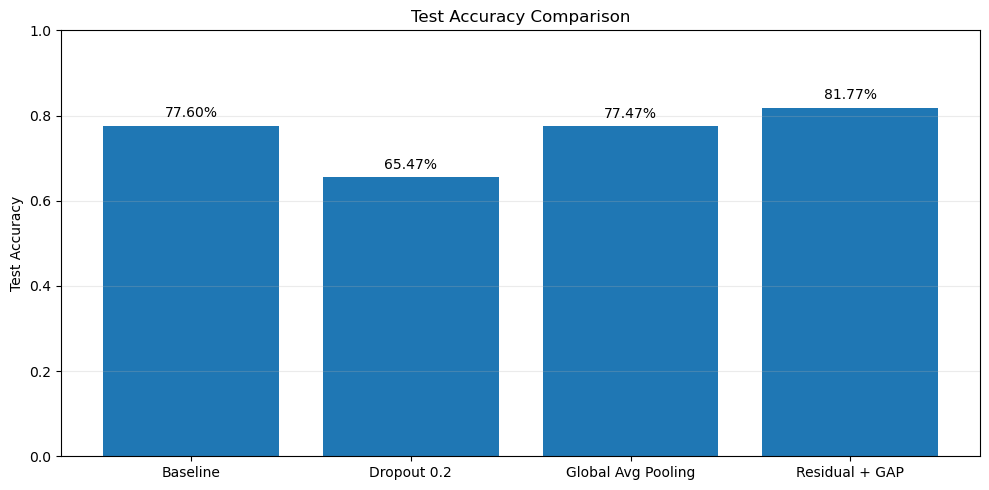

In [10]:
model_names = [
    "Baseline",
    "Dropout 0.2",
    "Global Avg Pooling",
    "Residual + GAP"
]
test_accuracies = [0.7760, 0.6547, 0.7747, 0.8177]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, test_accuracies)
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")

for bar, value in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# 8. Final Conclusion

The practical work followed a controlled improvement process rather than adding techniques randomly.

### Main conclusions

1. **Baseline CNN:** established the reference at **77.60%**.
2. **Lighter Dropout:** reduced performance to **65.47%**, so it was rejected.
3. **Global Average Pooling:** achieved **77.47%**, almost matching the baseline while providing a more compact representation.
4. **Residual + GAP:** achieved **81.77%**, giving the best test performance.

Therefore, the **Residual + Global Average Pooling model** is selected as the final model among the experiments performed.

The important point is not only that the final accuracy is higher. The experiments demonstrate the connection between the theoretical CNN techniques and practical model development:

**observe → identify a limitation → choose a relevant technique → experiment → evaluate → compare → conclude.**

